# InverseBench Test Data Visualization

This notebook loads, validates, summarizes, and visualizes held-out data for all five InverseBench scientific inverse problems.

## Shared setup

The repository root is located from the current working directory so dataset paths do not depend on whether Jupyter was started from the repository root or the `notebooks` directory.

In [21]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start=None):
    """Find the InverseBench root from a directory inside the checkout."""
    current = Path.cwd() if start is None else Path(start)
    current = current.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "training" / "dataset.py").is_file():
            return candidate
    raise RuntimeError(
        "Could not locate the InverseBench repository root. "
        "Start Jupyter from the repository root or one of its subdirectories."
    )


REPO_ROOT = find_repository_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from training.dataset import BlackHole, LMDBData, MultiCoilMRILMDBData

print(f"Repository root: {REPO_ROOT}")

Repository root: /home/hongkai/Code/InverseBench


### Reusable validation and display helpers

In [2]:
def load_validated_targets(dataset, sample_indices, expected_shape=(1, 128, 128)):
    """Load targets and fail early when a selection is not display-ready."""
    dataset_size = len(dataset)
    if dataset_size == 0:
        raise ValueError("The configured dataset is empty.")
    if not sample_indices:
        raise ValueError("Select at least one test sample index.")

    targets = []
    for index in sample_indices:
        if isinstance(index, (bool, np.bool_)) or not isinstance(index, (int, np.integer)):
            raise TypeError(f"Sample indices must be integers; received {index!r}.")
        if index < 0 or index >= dataset_size:
            raise IndexError(
                f"Sample index {index} is outside the dataset range "
                f"[0, {dataset_size - 1}]."
            )

        sample = dataset[int(index)]
        if not isinstance(sample, dict) or "target" not in sample:
            raise TypeError(f"Dataset sample {index} does not contain a 'target' value.")

        target = sample["target"]
        if hasattr(target, "detach"):
            target = target.detach().cpu().numpy()
        else:
            target = np.asarray(target)

        if target.shape != expected_shape:
            raise ValueError(
                f"Target {index} has shape {target.shape}; expected {expected_shape}."
            )
        if not np.isfinite(target).all():
            raise ValueError(f"Target {index} contains non-finite values.")
        targets.append(target)

    return np.stack(targets)


def report_selection(dataset, targets):
    """Print a compact summary of the loaded targets."""
    print(f"Dataset samples: {len(dataset)}")
    print(f"Selected samples: {len(targets)}")
    print(f"Target shape: {targets.shape[1:]}")
    print(f"Target dtype: {targets.dtype}")
    print(f"Target range: [{targets.min():.6g}, {targets.max():.6g}]")


def plot_grayscale_targets(targets, sample_indices):
    """Plot single-channel targets in a compact one-row layout."""
    if len(targets) != len(sample_indices):
        raise ValueError("Targets and sample indices must have the same length.")

    figure, axes = plt.subplots(
        1,
        len(sample_indices),
        figsize=(2.6 * len(sample_indices), 2.8),
        squeeze=False,
    )
    for axis, target, index in zip(axes[0], targets, sample_indices):
        axis.imshow(target[0], cmap="gray", vmin=0.0, vmax=1.0)
        axis.set_title(f"Test {index}", fontsize=10, pad=4)
        axis.set_axis_off()

    figure.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.9, wspace=0.04)
    return figure, axes

## Linear inverse scattering

Load four raw permittivity targets from the test LMDB. Edit the path and indices below to match your local data and preferred examples. The dataset is available from the [InverseBench CaltechData record](https://data.caltech.edu/records/zg89b-mpv16), also linked in `Dataset_Card.md`.

In [3]:
# Edit these values for your local test data and desired examples.
INV_SCATTER_TEST_PATH = (REPO_ROOT / "../data/inv-scatter-test").resolve()
INV_SCATTER_SAMPLE_INDICES = [0, 1, 2, 3]

print(f"Linear inverse scattering data: {INV_SCATTER_TEST_PATH}")
print(f"Selected indices: {INV_SCATTER_SAMPLE_INDICES}")

Linear inverse scattering data: /home/hongkai/Code/data/inv-scatter-test
Selected indices: [0, 1, 2, 3]


In [4]:
if not INV_SCATTER_TEST_PATH.exists():
    raise FileNotFoundError(
        f"Linear inverse scattering test data was not found at "
        f"{INV_SCATTER_TEST_PATH}. Edit INV_SCATTER_TEST_PATH above after "
        "downloading the data from the CaltechData source linked in Dataset_Card.md."
    )

try:
    inv_scatter_dataset = LMDBData(
        root=str(INV_SCATTER_TEST_PATH),
        resolution=128,
        raw_resolution=128,
        num_channels=1,
        norm=False,
    )
except Exception as error:
    raise RuntimeError(
        f"Could not open {INV_SCATTER_TEST_PATH} as an LMDB dataset. "
        "Check that the path contains the extracted linear inverse scattering test data."
    ) from error

In [5]:
inv_scatter_targets = load_validated_targets(
    inv_scatter_dataset,
    INV_SCATTER_SAMPLE_INDICES,
)
report_selection(inv_scatter_dataset, inv_scatter_targets)

Dataset samples: 100
Selected samples: 4
Target shape: (1, 128, 128)
Target dtype: float32
Target range: [0, 1]


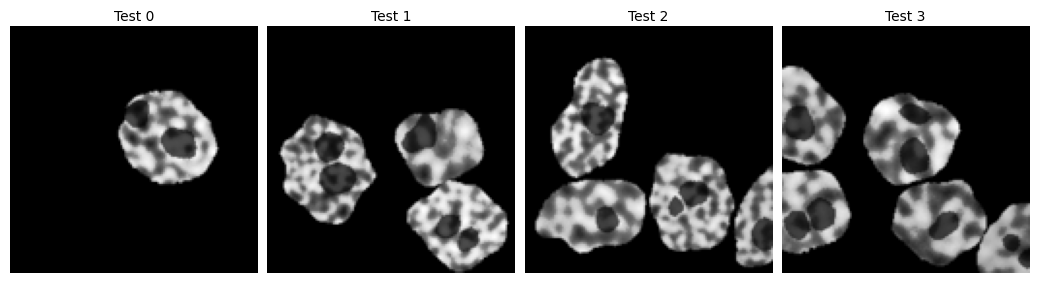

In [6]:
inv_scatter_figure, inv_scatter_axes = plot_grayscale_targets(
    inv_scatter_targets,
    INV_SCATTER_SAMPLE_INDICES,
)
plt.show()

## MRI

Display magnitude images reconstructed from the complex-valued knee MRI targets. The images use a black-to-white grayscale window with hidden axes and no colorbar, matching the reference style. Download and extract [`knee_test_lmdb.zip`](https://data.caltech.edu/api/records/zg89b-mpv16/files/knee_test_lmdb.zip/content) from the InverseBench CaltechData record.

In [13]:
# Edit these values for your local test data and desired examples.
MRI_TEST_PATH = (REPO_ROOT / "../data/knee_test_lmdb").resolve()
MRI_SAMPLE_INDICES = [40, 50, 60, 70]
MRI_IMAGE_SIZE = (320, 320)

print(f"Knee MRI data: {MRI_TEST_PATH}")
print(f"Selected indices: {MRI_SAMPLE_INDICES}")

Knee MRI data: /home/hongkai/Code/data/knee_test_lmdb
Selected indices: [40, 50, 60, 70]


In [14]:
def load_mri_magnitudes(dataset, sample_indices, image_size=(320, 320)):
    """Load two-channel complex MRI targets and return their magnitudes."""
    dataset_size = len(dataset)
    if dataset_size == 0:
        raise ValueError("The configured MRI dataset is empty.")
    if not sample_indices:
        raise ValueError("Select at least one MRI test sample index.")

    expected_shape = (2, *image_size)
    magnitudes = []
    for index in sample_indices:
        if isinstance(index, (bool, np.bool_)) or not isinstance(index, (int, np.integer)):
            raise TypeError(f"MRI sample indices must be integers; received {index!r}.")
        if index < 0 or index >= dataset_size:
            raise IndexError(
                f"MRI sample index {index} is outside the dataset range "
                f"[0, {dataset_size - 1}]."
            )

        sample = dataset[int(index)]
        target = sample["target"] if isinstance(sample, dict) and "target" in sample else sample
        if hasattr(target, "detach"):
            target = target.detach().cpu().numpy()
        else:
            target = np.asarray(target)

        if target.shape != expected_shape:
            raise ValueError(
                f"MRI target {index} has shape {target.shape}; expected {expected_shape} "
                "with real and imaginary channels."
            )
        if not np.isfinite(target).all():
            raise ValueError(f"MRI target {index} contains non-finite values.")

        magnitude = np.sqrt(np.square(target[0]) + np.square(target[1]))
        magnitudes.append(magnitude)

    return np.stack(magnitudes)


def report_mri_selection(dataset, magnitudes):
    """Print a compact summary of the selected MRI magnitude images."""
    print(f"Dataset samples: {len(dataset)}")
    print(f"Selected samples: {len(magnitudes)}")
    print(f"Magnitude shape: {magnitudes.shape[1:]}")
    print(f"Magnitude dtype: {magnitudes.dtype}")
    print(f"Magnitude range: [{magnitudes.min():.6g}, {magnitudes.max():.6g}]")


def plot_mri_magnitudes(magnitudes):
    """Render MRI magnitudes as tightly spaced, axis-free grayscale images."""
    if len(magnitudes) == 0:
        raise ValueError("At least one MRI magnitude image is required.")

    figure, axes = plt.subplots(
        1,
        len(magnitudes),
        figsize=(2.6 * len(magnitudes), 2.6),
        squeeze=False,
    )
    for axis, magnitude in zip(axes[0], magnitudes):
        axis.imshow(magnitude, cmap="gray", vmin=0.0, vmax=1.0)
        axis.set_facecolor("black")
        axis.set_axis_off()

    figure.patch.set_facecolor("white")
    figure.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0, wspace=0.02)
    return figure, axes

In [15]:
if not MRI_TEST_PATH.exists():
    raise FileNotFoundError(
        f"Knee MRI test data was not found at {MRI_TEST_PATH}. "
        "Download and extract knee_test_lmdb.zip from the CaltechData source, "
        "then edit MRI_TEST_PATH above."
    )
if not (MRI_TEST_PATH / "mvue").exists():
    raise FileNotFoundError(
        f"{MRI_TEST_PATH} does not contain the expected 'mvue' LMDB directory. "
        "Point MRI_TEST_PATH to the extracted knee_test_lmdb directory."
    )

try:
    mri_dataset = MultiCoilMRILMDBData(
        root=MRI_TEST_PATH,
        image_size=MRI_IMAGE_SIZE,
        mvue_only=True,
    )
except Exception as error:
    raise RuntimeError(
        f"Could not open {MRI_TEST_PATH} as a knee MRI LMDB dataset. "
        "Check that knee_test_lmdb.zip was fully extracted."
    ) from error

In [16]:
mri_magnitudes = load_mri_magnitudes(
    mri_dataset,
    MRI_SAMPLE_INDICES,
    MRI_IMAGE_SIZE,
)
report_mri_selection(mri_dataset, mri_magnitudes)

Dataset samples: 96
Selected samples: 4
Magnitude shape: (320, 320)
Magnitude dtype: float32
Magnitude range: [3.31708e-05, 1.81123]


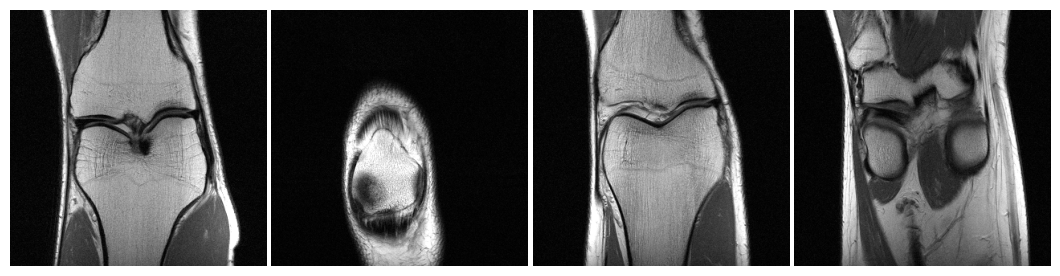

In [17]:
mri_figure, mri_axes = plot_mri_magnitudes(mri_magnitudes)
plt.show()

## Black hole imaging

Display synthetic black-hole targets with a black–red–yellow–white intensity map, hidden axes, and no colorbar. Download and extract [`blackhole.zip`](https://data.caltech.edu/api/records/zg89b-mpv16/files/blackhole.zip/content) from the InverseBench CaltechData record.

In [22]:
# Edit these values for your local test data and desired examples.
BLACKHOLE_TEST_PATH = (REPO_ROOT / "../data/blackhole/test").resolve()
BLACKHOLE_SAMPLE_INDICES = [0, 1, 2, 3]
BLACKHOLE_IMAGE_SIZE = 64

print(f"Black-hole imaging data: {BLACKHOLE_TEST_PATH}")
print(f"Selected indices: {BLACKHOLE_SAMPLE_INDICES}")

Black-hole imaging data: /home/hongkai/Code/data/blackhole/test
Selected indices: [0, 1, 2, 3]


In [23]:
def load_blackhole_targets(dataset, sample_indices, image_size=64):
    """Load normalized black-hole targets and map them from [-1, 1] to [0, 1]."""
    dataset_size = len(dataset)
    if dataset_size == 0:
        raise ValueError("The configured black-hole dataset is empty.")
    if not sample_indices:
        raise ValueError("Select at least one black-hole test sample index.")

    expected_shape = (1, image_size, image_size)
    images = []
    for index in sample_indices:
        if isinstance(index, (bool, np.bool_)) or not isinstance(index, (int, np.integer)):
            raise TypeError(f"Black-hole sample indices must be integers; received {index!r}.")
        if index < 0 or index >= dataset_size:
            raise IndexError(
                f"Black-hole sample index {index} is outside the dataset range "
                f"[0, {dataset_size - 1}]."
            )

        sample = dataset[int(index)]
        if not isinstance(sample, dict) or "target" not in sample:
            raise TypeError(f"Black-hole sample {index} does not contain a 'target' value.")

        target = sample["target"]
        if hasattr(target, "detach"):
            target = target.detach().cpu().numpy()
        else:
            target = np.asarray(target)

        if target.shape != expected_shape:
            raise ValueError(
                f"Black-hole target {index} has shape {target.shape}; expected {expected_shape}."
            )
        if not np.isfinite(target).all():
            raise ValueError(f"Black-hole target {index} contains non-finite values.")

        images.append(np.clip((target[0] + 1.0) / 2.0, 0.0, 1.0))

    return np.stack(images)


def report_blackhole_selection(dataset, images):
    """Print a compact summary of the selected black-hole images."""
    print(f"Dataset samples: {len(dataset)}")
    print(f"Selected samples: {len(images)}")
    print(f"Image shape: {images.shape[1:]}")
    print(f"Image dtype: {images.dtype}")
    print(f"Image range: [{images.min():.6g}, {images.max():.6g}]")


def plot_blackhole_targets(images):
    """Render black-hole targets with the reference-style thermal colormap."""
    if len(images) == 0:
        raise ValueError("At least one black-hole image is required.")

    figure, axes = plt.subplots(
        1,
        len(images),
        figsize=(2.6 * len(images), 2.6),
        squeeze=False,
    )
    for axis, image in zip(axes[0], images):
        axis.imshow(
            image,
            cmap="afmhot",
            vmin=0.0,
            vmax=1.0,
            interpolation="bicubic",
        )
        axis.set_facecolor("black")
        axis.set_axis_off()

    figure.patch.set_facecolor("white")
    figure.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0, wspace=0.02)
    return figure, axes

In [24]:
if not BLACKHOLE_TEST_PATH.exists():
    raise FileNotFoundError(
        f"Black-hole test data was not found at {BLACKHOLE_TEST_PATH}. "
        "Download and extract blackhole.zip from the CaltechData source, "
        "then edit BLACKHOLE_TEST_PATH above."
    )

try:
    blackhole_dataset = BlackHole(
        root=str(BLACKHOLE_TEST_PATH),
        resolution=BLACKHOLE_IMAGE_SIZE,
        original_resolution=BLACKHOLE_IMAGE_SIZE,
        random_flip=False,
        zoom_in_out=False,
    )
except Exception as error:
    raise RuntimeError(
        f"Could not open {BLACKHOLE_TEST_PATH} as a black-hole LMDB dataset. "
        "Check that blackhole.zip was fully extracted."
    ) from error

In [25]:
blackhole_images = load_blackhole_targets(
    blackhole_dataset,
    BLACKHOLE_SAMPLE_INDICES,
    BLACKHOLE_IMAGE_SIZE,
)
report_blackhole_selection(blackhole_dataset, blackhole_images)

Dataset samples: 100
Selected samples: 4
Image shape: (64, 64)
Image dtype: float64
Image range: [0, 1]


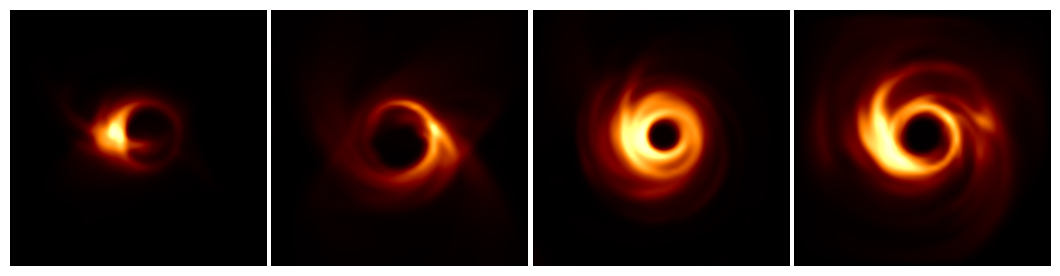

In [26]:
blackhole_figure, blackhole_axes = plot_blackhole_targets(blackhole_images)
plt.show()

## Full waveform inversion

Display acoustic velocity models in km/s with the reference `jet` colormap, spatial pixel coordinates, and a shared color scale from 1 to 5 km/s. Download and extract [`fwi-test.zip`](https://data.caltech.edu/api/records/zg89b-mpv16/files/fwi-test.zip/content) from the InverseBench CaltechData record.

In [27]:
# Edit these values for your local test data and desired examples.
FWI_TEST_PATH = (REPO_ROOT / "../data/fwi-test").resolve()
FWI_SAMPLE_INDICES = [1, 2, 3, 4]
FWI_IMAGE_SIZE = 128
FWI_RAW_IMAGE_SIZE = 70

print(f"Full waveform inversion data: {FWI_TEST_PATH}")
print(f"Selected indices: {FWI_SAMPLE_INDICES}")

Full waveform inversion data: /home/hongkai/Code/data/fwi-test
Selected indices: [1, 2, 3, 4]


In [28]:
def load_fwi_velocities(dataset, sample_indices, image_size=128):
    """Load FWI targets and convert velocity from m/s to km/s."""
    dataset_size = len(dataset)
    if dataset_size == 0:
        raise ValueError("The configured FWI dataset is empty.")
    if not sample_indices:
        raise ValueError("Select at least one FWI test sample index.")

    expected_shape = (1, image_size, image_size)
    velocities = []
    for index in sample_indices:
        if isinstance(index, (bool, np.bool_)) or not isinstance(index, (int, np.integer)):
            raise TypeError(f"FWI sample indices must be integers; received {index!r}.")
        if index < 0 or index >= dataset_size:
            raise IndexError(
                f"FWI sample index {index} is outside the dataset range "
                f"[0, {dataset_size - 1}]."
            )

        sample = dataset[int(index)]
        if not isinstance(sample, dict) or "target" not in sample:
            raise TypeError(f"FWI sample {index} does not contain a 'target' value.")

        target = sample["target"]
        if hasattr(target, "detach"):
            target = target.detach().cpu().numpy()
        else:
            target = np.asarray(target)

        if target.shape != expected_shape:
            raise ValueError(
                f"FWI target {index} has shape {target.shape}; expected {expected_shape}."
            )
        if not np.isfinite(target).all():
            raise ValueError(f"FWI target {index} contains non-finite values.")

        velocities.append(target[0] / 1000.0)

    return np.stack(velocities)


def report_fwi_selection(dataset, velocities):
    """Print a compact summary of the selected velocity models."""
    print(f"Dataset samples: {len(dataset)}")
    print(f"Selected samples: {len(velocities)}")
    print(f"Velocity shape: {velocities.shape[1:]}")
    print(f"Velocity dtype: {velocities.dtype}")
    print(f"Velocity range: [{velocities.min():.6g}, {velocities.max():.6g}] km/s")


def plot_fwi_velocities(velocities):
    """Render velocity maps with a shared 1–5 km/s color scale."""
    if len(velocities) == 0:
        raise ValueError("At least one FWI velocity model is required.")

    figure, axes = plt.subplots(
        1,
        len(velocities),
        figsize=(3.2 * len(velocities) + 0.6, 3.0),
        squeeze=False,
    )
    image_artist = None
    for axis, velocity in zip(axes[0], velocities):
        image_artist = axis.imshow(
            velocity,
            cmap="jet",
            vmin=1.0,
            vmax=5.0,
            interpolation="nearest",
        )

    figure.subplots_adjust(left=0.04, right=0.93, bottom=0.12, top=0.98, wspace=0.28)
    colorbar_axis = figure.add_axes((0.95, 0.12, 0.015, 0.86))
    colorbar = figure.colorbar(image_artist, cax=colorbar_axis)
    colorbar.set_ticks(np.arange(1.0, 5.01, 0.5))
    return figure, axes, colorbar

In [29]:
if not FWI_TEST_PATH.exists():
    raise FileNotFoundError(
        f"FWI test data was not found at {FWI_TEST_PATH}. "
        "Download and extract fwi-test.zip from the CaltechData source, "
        "then edit FWI_TEST_PATH above."
    )

try:
    fwi_dataset = LMDBData(
        root=str(FWI_TEST_PATH),
        resolution=FWI_IMAGE_SIZE,
        raw_resolution=FWI_RAW_IMAGE_SIZE,
        num_channels=1,
        norm=False,
    )
except Exception as error:
    raise RuntimeError(
        f"Could not open {FWI_TEST_PATH} as an FWI LMDB dataset. "
        "Check that fwi-test.zip was fully extracted."
    ) from error

In [30]:
fwi_velocities = load_fwi_velocities(
    fwi_dataset,
    FWI_SAMPLE_INDICES,
    FWI_IMAGE_SIZE,
)
report_fwi_selection(fwi_dataset, fwi_velocities)

Dataset samples: 100
Selected samples: 4
Velocity shape: (128, 128)
Velocity dtype: float32
Velocity range: [1.568, 4.435] km/s


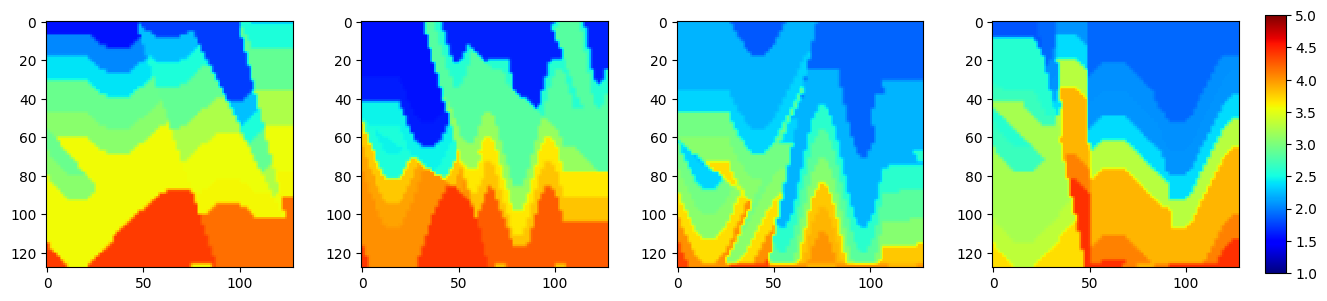

In [31]:
fwi_figure, fwi_axes, fwi_colorbar = plot_fwi_velocities(fwi_velocities)
plt.show()

## Navier–Stokes

Display Reynolds-200 vorticity fields after five simulation time units. The reversed `Spectral` colormap maps negative vorticity to blue and positive vorticity to red over a fixed symmetric range of `[-10, 10]`. Download and extract [`navier-stokes-test.zip`](https://data.caltech.edu/api/records/zg89b-mpv16/files/navier-stokes-test.zip/content) from the InverseBench CaltechData record.

In [ ]:
# Edit these values for your local test data and desired examples.
NAVIER_STOKES_TEST_PATH = (
    REPO_ROOT / "../data/navier-stokes-test/Re200.0-t5.0"
).resolve()
NAVIER_STOKES_SAMPLE_INDICES = [0, 1, 2, 3]
NAVIER_STOKES_IMAGE_SIZE = 128

print(f"Navier–Stokes data: {NAVIER_STOKES_TEST_PATH}")
print(f"Selected indices: {NAVIER_STOKES_SAMPLE_INDICES}")

In [ ]:
def load_vorticity_fields(dataset, sample_indices, image_size=128):
    """Load raw single-channel Navier–Stokes vorticity fields."""
    dataset_size = len(dataset)
    if dataset_size == 0:
        raise ValueError("The configured Navier–Stokes dataset is empty.")
    if not sample_indices:
        raise ValueError("Select at least one Navier–Stokes test sample index.")

    expected_shape = (1, image_size, image_size)
    fields = []
    for index in sample_indices:
        if isinstance(index, (bool, np.bool_)) or not isinstance(index, (int, np.integer)):
            raise TypeError(
                f"Navier–Stokes sample indices must be integers; received {index!r}."
            )
        if index < 0 or index >= dataset_size:
            raise IndexError(
                f"Navier–Stokes sample index {index} is outside the dataset range "
                f"[0, {dataset_size - 1}]."
            )

        sample = dataset[int(index)]
        if not isinstance(sample, dict) or "target" not in sample:
            raise TypeError(
                f"Navier–Stokes sample {index} does not contain a 'target' value."
            )

        target = sample["target"]
        if hasattr(target, "detach"):
            target = target.detach().cpu().numpy()
        else:
            target = np.asarray(target)

        if target.shape != expected_shape:
            raise ValueError(
                f"Navier–Stokes target {index} has shape {target.shape}; "
                f"expected {expected_shape}."
            )
        if not np.isfinite(target).all():
            raise ValueError(f"Navier–Stokes target {index} contains non-finite values.")

        fields.append(target[0])

    return np.stack(fields)


def report_vorticity_selection(dataset, fields):
    """Print a compact summary of the selected vorticity fields."""
    print(f"Dataset samples: {len(dataset)}")
    print(f"Selected samples: {len(fields)}")
    print(f"Vorticity shape: {fields.shape[1:]}")
    print(f"Vorticity dtype: {fields.dtype}")
    print(f"Vorticity range: [{fields.min():.6g}, {fields.max():.6g}]")


def plot_vorticity_fields(fields):
    """Render vorticity with a fixed blue-to-red diverging scale."""
    if len(fields) == 0:
        raise ValueError("At least one vorticity field is required.")

    figure, axes = plt.subplots(
        1,
        len(fields),
        figsize=(2.6 * len(fields), 2.6),
        squeeze=False,
    )
    for axis, field in zip(axes[0], fields):
        axis.imshow(
            field,
            cmap="Spectral_r",
            vmin=-10.0,
            vmax=10.0,
            interpolation="bilinear",
        )
        axis.set_axis_off()

    figure.patch.set_facecolor("white")
    figure.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0, wspace=0.02)
    return figure, axes

In [ ]:
if not NAVIER_STOKES_TEST_PATH.exists():
    raise FileNotFoundError(
        f"Navier–Stokes test data was not found at {NAVIER_STOKES_TEST_PATH}. "
        "Download and extract navier-stokes-test.zip from the CaltechData source, "
        "then edit NAVIER_STOKES_TEST_PATH above."
    )

try:
    navier_stokes_dataset = LMDBData(
        root=str(NAVIER_STOKES_TEST_PATH),
        resolution=NAVIER_STOKES_IMAGE_SIZE,
        raw_resolution=NAVIER_STOKES_IMAGE_SIZE,
        num_channels=1,
        norm=False,
    )
except Exception as error:
    raise RuntimeError(
        f"Could not open {NAVIER_STOKES_TEST_PATH} as a Navier–Stokes LMDB dataset. "
        "Check that navier-stokes-test.zip was fully extracted."
    ) from error

In [ ]:
vorticity_fields = load_vorticity_fields(
    navier_stokes_dataset,
    NAVIER_STOKES_SAMPLE_INDICES,
    NAVIER_STOKES_IMAGE_SIZE,
)
report_vorticity_selection(navier_stokes_dataset, vorticity_fields)

In [ ]:
navier_stokes_figure, navier_stokes_axes = plot_vorticity_fields(vorticity_fields)
plt.show()